<a href="https://colab.research.google.com/github/MarioFloresUnizar/Codigo_TFG_Procesos_semileptonicos/blob/main/Cuaderno_1_(8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> ANÁLISIS DE DATOS Y CÁLCULO DEL ELEMENTO $|V_{cb}|$ </h1>

Partimos de un archivo que contiene un conjunto de funciones de correlación, las cuales contienen información de transiciones débiles entre los mesones $B$ y $D^*$ y $B_s$ y $D_s^*$ , llevadas a cabo en una simulación en Lattice. Estas funciones de correlación son claves para describir estas desintegraciones, ya que, con un tratamiento adecuado de estas, podemos obtener elementos de matriz que pueden ser utilizados para describir la amplitud de transición entre distintos estados, diversos factores de forma relevantes para cálculos de ritmos de desintegración y, consecuentemente, la probabilidad de transición entre dos estados. <br>


La motivación y objetivo de este cuaderno de código es la obtención de dichas funciones de correlación y posterior tratamiento de estas para obtener amplitudes de transición entre los estados mesónicos $B$ y $D^*$ y $B_s$ y $D_s^*$, el factor de forma $h_{A_1}(\omega = 1)$ y, finalmente, el elemento $|V_{cb}|$ de la matriz $CKM$.

Debido a que el archivo es de tipo $\textbf{.hdf5}$, haremos uso del paquete $\textbf{h5py}$ para la lectura de datos de dicho archivo, además de los paquetes $\textbf{numpy}$ para tratamiento con arrays básico, $\textbf{math}$ para unos detalles requeridos posteriormente en el tratamiento estadístico de los datos y $\textbf{matplotlib}$ para la representación gráfica de diversas funciones.

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import math

<br>

<h2> 1. FUNCIONES DE CORRELACIÓN A 2 PUNTOS </h2>


Comenzamos abriendo el archivo y extrayendo las funciones de correlación a 2 puntos. Estas funciones a 2 puntos expresan la probabilidad de encontrar una partícula en un punto dado, si se ha creado en otro punto. Habrá una función por cada partícula, pero para el caso de las partículas $D^*$y $D_s^*$, al tratarse de partículas vectoriales (partículas de spin total $J=1$), habrá 3 funciones, una para cada dirección del espacio. Las funciones tienen un determinado nombre distintivo, llamado $\text{correlador}$, con el cual podemos leerla directamente de nuestro archivo.
<br>

In [ ]:
myFile = h5py.File('Ensembles/FnalHISQ/a0.12/l3264f211b600m00507m0507m628-HISQscript.hdf5', 'r')

dataB = np.array (myFile['data']["P5_P5_1S_RW_1S_d_k0.08574_m0.00507_p000"])

dataD_x = np.array (myFile['data']["V1_V1_1S_RW_1S_d_k0.12201_m0.00507_p000"])
dataD_y = np.array (myFile['data']["V2_V2_1S_RW_1S_d_k0.12201_m0.00507_p000"])
dataD_z = np.array (myFile['data']["V3_V3_1S_RW_1S_d_k0.12201_m0.00507_p000"])

dataD_tot = np.array([dataD_x, dataD_y, dataD_z])  # Almaceno las 3 componentes espaciales en un único array

dataB_s = np.array(myFile['data']["P5_P5_1S_RW_1S_d_k0.08574_m0.0507_p000"])

dataD_s_x = np.array(myFile['data']["V1_V1_1S_RW_1S_d_k0.12201_m0.0507_p000"])
dataD_s_y = np.array(myFile['data']["V2_V2_1S_RW_1S_d_k0.12201_m0.0507_p000"])
dataD_s_z = np.array(myFile['data']["V3_V3_1S_RW_1S_d_k0.12201_m0.0507_p000"])

dataD_s_tot = np.array([dataD_s_x, dataD_s_y, dataD_s_z])

<br>

Las funciones que hemos obtenido se tratan de matrices 1000x64. Estas dimensiones representan 1000 configuraciones distintas para 64 tiempos, de forma que el tiempo $t\in[0, 63]$. Esto es debido al tamaño temporal $T=64$ del retículo de Lattice utilizado para la simulación.


Como cada elemento de la función de correlación depende del campo gluónico,  $\mathcal{U}$, (en nuestro caso los campos gauge débiles), es decir, $C_i(t)=C(\mathcal{U}_i, t)$ cada configuración se distingue de otra porque se tratan  de los distintos valores que la función de correlación toma para distintos valores de dicho campo. A nosotros nos interesa el valor esperado de dicha función de correlación para un tiempo determinado a lo largo de los posibles valores del campo, por lo que vamos a promediar a lo largo de las configuraciones para obtener este valor esperado $\langle C(t) \rangle \equiv C(t)$. En el caso de las partículas $D^*$ y $D_s^*$ hacemos primero un promedio a lo largo de las 3 direcciones del espacio por su carácter vectorial. Además, calculamos las matrices de covarianza de los vectores resultantes para, seguidamente, obtener las incertidumbres asociadas a las funciones de correlación.

In [ ]:
#Para cada tiempo, calculo el valor medio sobre todas las configuraciones
#Obtenemos arrays 1D de 64 componentes

dataD = np.mean(dataD_tot, 0)     #primero promedio sobre las direcciones X, Y, Z es decir, X+Y+Z/3
dataD_s = np.mean(dataD_s_tot, 0)   #obtenemos un array 1000x64

corrB = np.mean(dataB, 0)
corrD = np.mean(dataD, 0)            #y luego promedio sobre las configuraciones
corrB_s = np.mean(dataB_s, 0)      #obtenemos array (vector) de 64 comp.
corrD_s = np.mean(dataD_s, 0)

#Matrices de covarianza de los datos

covB = np.cov(dataB, rowvar=False)
covD = np.cov(dataD, rowvar=False)     #calculamos las matrices de covarianza sobre los promedios de las direcciones X, Y, Z
covB_s = np.cov(dataB_s, rowvar=False)
covD_s = np.cov(dataD_s, rowvar=False)


errB = np.sqrt(covB.diagonal())
errD = np.sqrt(covD.diagonal())
errB_s = np.sqrt(covB_s.diagonal())
errD_s = np.sqrt(covD_s.diagonal())


<br>

Las funciones $C(t)$ asociadas a las distintas partículas tienen una forma simétrica, pues siguen una expresión del tipo:

$$
C(t) \approx A \ [e^{-E\ t} + e^{-E\ (T-t)}]
\tag{1}
$$
Siendo $A$ la amplitud de la función y $E$ la energía del estado en el que se encuentre el mesón.

Con el eje de ordenadas en escala logarítmica, estas funciones tendrán forma de $\textbf{V}$ con el pico situado en $t_0 =T/2=32$.
Por ello, decidimos realizar un $\textbf{folding}$ , es decir, un "doblado" o "pliegue" de nuestra función en torno a $t_0$. Esto lo hacemos promediando entre puntos simétricos $t$ y $T-t$ y representando gráficamente solo hasta $t=32$. Además, añadimos otra función para que calcule las incertidumbres asociadas a nuestras nuevas variables.

Podríamos haber realizado un ajuste de $C(t)$ a la función $f(t)=A \ [e^{-E\ t} + e^{-E\ (T-t)}]$ y comprobar que el comportamiento es el esperado, pero hemos optado por un folding para más comodidad visual a la hora de representarlo gráficamente, ya que, por el momento, no nos es relevante ningún parámetro del ajuste.

In [ ]:
#ya tenemos las medias de los datos y sus errores asociados
#A continuación, realizamos un folding de los datos por su simetría debida a las condiciones de contorno

def folding (vector):
    T = len(vector)
    Amax = math.ceil(T/2)
    a = np.zeros(Amax)
    for i in range(Amax):
        a[i] = vector[i] + vector[T-1-i]
    return a/2

#Y nos calculamos tambien los errores asociados, teniendo en cuenta la propagacion de errores de las medias

def err_folding (vector):
    T = len(vector)
    Amax = math.ceil(T/2)
    a = np.zeros(Amax)
    for i in range(Amax):
        a[i] = np.sqrt(vector[i]**2 + vector[T-i-1]**2)
    return a/2




<br>

Aplicamos el folding a nuestras funciones $C(t)$ y representamos gráficamente para observar su comportamiento.

<br>

In [ ]:
foldedB = folding(corrB)
foldedD = folding(corrD)
foldedB_s = folding(corrB_s)
foldedD_s = folding(corrD_s)

err_foldedB = err_folding(errB)
err_foldedD = err_folding(errD)
err_foldedB_s = err_folding(errB_s)
err_foldedD_s = err_folding(errD_s)

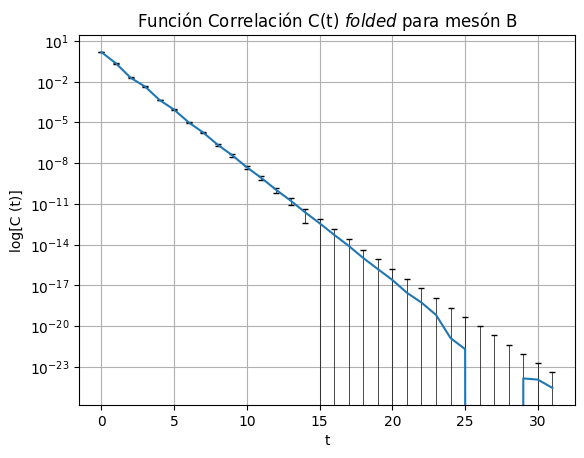

In [ ]:
T = len(corrB)
C = dataB.shape[0]
L = len(foldedB)


rango_t = np.linspace(0, L-1, L)

plt.yscale('log')
plt.errorbar(rango_t, foldedB, err_foldedB, ecolor='k', elinewidth=0.5, capsize=2)

plt.xlabel('t')
plt.ylabel('log[C (t)]')
plt.title('Función Correlación C(t) $folded$ para mesón B')
plt.grid(True)
plt.show()


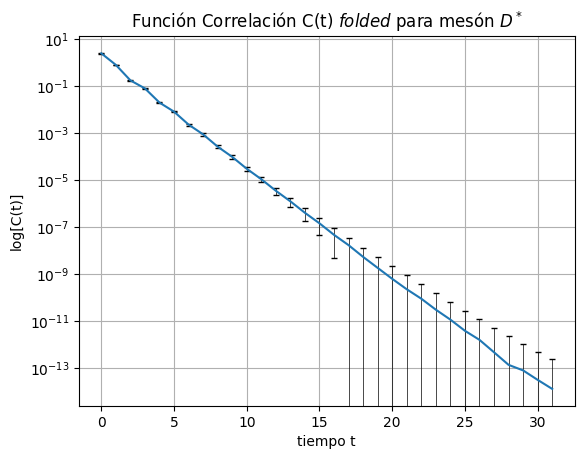

In [ ]:
plt.yscale('log')
plt.errorbar(rango_t, foldedD, err_foldedD, ecolor='k',elinewidth=0.5, capsize=2)

plt.xlabel('tiempo t')
plt.ylabel('log[C(t)]')
plt.title('Función Correlación C(t) $folded$ para mesón $D^*$')
plt.grid(True)
plt.show()

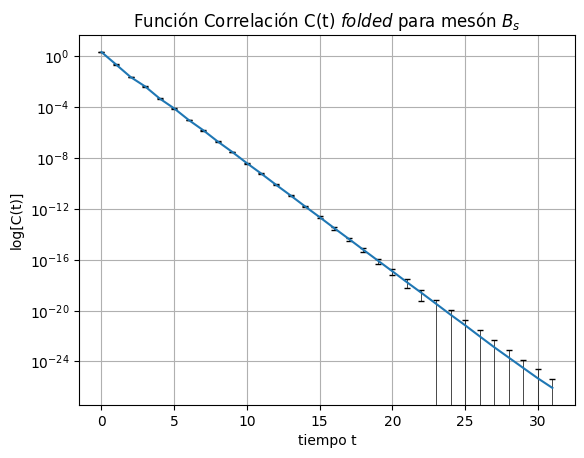

In [ ]:
plt.yscale('log')
plt.errorbar(rango_t, foldedB_s, err_foldedB_s, ecolor='k',elinewidth=0.5, capsize=2)

plt.xlabel('tiempo t')
plt.ylabel('log[C(t)]')
plt.title('Función Correlación C(t) $folded$ para mesón $B_s$')
plt.grid(True)
plt.show()

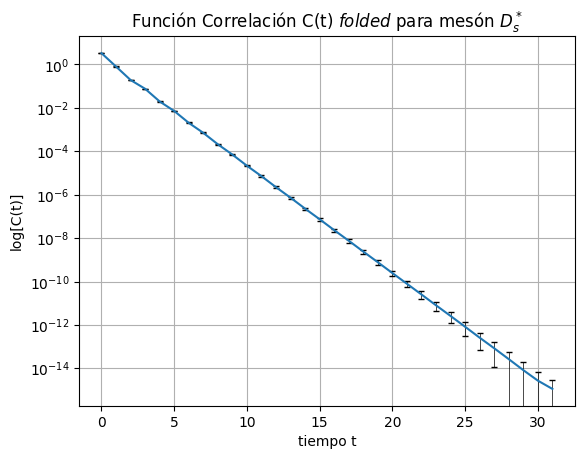

In [ ]:
plt.yscale('log')
plt.errorbar(rango_t, foldedD_s, err_foldedD_s, ecolor='k',elinewidth=0.5, capsize=2)

plt.xlabel('tiempo t')
plt.ylabel('log[C(t)]')
plt.title('Función Correlación C(t) $folded$ para mesón $D^*_s$')
plt.grid(True)
plt.show()

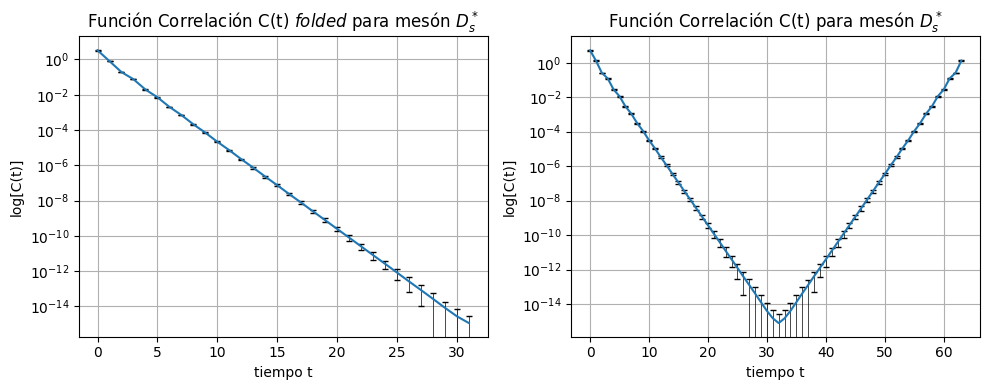

In [ ]:
rango_T = np.linspace(0, T-1, T)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.set_yscale('log')
ax1.errorbar(rango_t, foldedD_s, err_foldedD_s, ecolor='k',elinewidth=0.5, capsize=2)
ax1.set_xlabel('tiempo t')
ax1.set_ylabel('log[C(t)]')
ax1.set_title('Función Correlación C(t) $folded$ para mesón $D^*_s$')
ax1.grid(True)

ax2.set_yscale('log')
ax2.errorbar(rango_T, corrD_s, errD_s, ecolor='k',elinewidth=0.5, capsize=2)
ax2.set_xlabel('tiempo t')
ax2.set_ylabel('log[C(t)]')
ax2.set_title('Función Correlación C(t) para mesón $D^*_s$')
ax2.grid(True)

plt.tight_layout()
plt.show()

Observamos que efectivamente el comportamiento es el esperado. Podemos observar también la comparación entre las funciones de correlación folded, a la izquierda, y sin realizar folding, a la derecha.

<h2> 2. HERRAMIENTAS PARA EL TRATAMIENTO ESTADÍSTICO DE LOS DATOS </h2>

A continuación definimos las herramientas estadísticas que vamos a utilizar para tratar las funciones de correlación: $\textbf{binning}$ y $\textbf{jackknife}$.

El binning es una herramienta a través de la cual agrupamos un conjunto de valores en uno solo, que será la media de los anteriores. Es decir, si tenemos un vector de tamaño $N$, el resultado de aplicar un binning de tamaño $B$ a este vector, será un nuevo vector de tamaño $L=N/B$ cuyas componentes serán las medias de $B$ valores del vector original. La primera componente será la media de las primeras $B$ componentes del vector inicial, la segunda componente la media de las $B$ siguientes y así sucesivamente. Si el tamaño $N$ no es divisible entre $B$, la última componente del vector de binning será la media de las $r = N\ (mod\ B)$ últimas componentes del vector original. El binning será aplicado a lo largo de las configuraciones para reducir nuestro set inicial de datos, ya que muchas configuraciones contiguas no son totalmente independientes entre sí.

Por otro lado, el jackknife aplicado sobre un vector de $N$ componentes, consiste en crear un nuevo vector cuya componente i-ésima sea la media del vector inicial menos la componente i-ésima, de forma que el vector resultante tiene también $N$ componentes. Esto nos proporcionará una forma medir incertidumbres sobre nuestro set de datos. Tras aplicar un jackknife sobre nuestro set de datos (también lo aplicaremos a lo largo de las configuraciones), tenemos que calcular un nuevo estimador de la matriz de covarianza debido a que los nuevos valores no son independientes entre sí. La matriz de covarianza de jackknife se define entonces como:  $Cov^{\ jackk}=(N-1)^2\ Cov^{\ naive}$.

In [ ]:
def binning (data, n_bin):
    N = len(data)
    N_f = math.ceil(N /n_bin)
    binn = np.zeros(N_f)
    cont = 0
    for i in range (N_f-1):
        binn [i] = sum(data[cont: n_bin+cont])/n_bin
        cont += n_bin
    binn[N_f-1] = sum(data[cont: N])/(N-cont)
    return binn

def jackknife (data):
    N = len(data)
    tot = sum(data)
    jackk = np.zeros(N)
    for i in range (N):
        jackk[i] =  tot - data[i]
    jackk = jackk/(N-1)
    return jackk

def mean_cov_jackk(data, n_bin, jackk_matrix = True, cov_matrix = True):  # he añadido el bool corr_function por comodidad para comparar los errores
    N0 = math.ceil(data.shape[0]/n_bin)                 # posteriormente para t=10
    N1 = data.shape[1]
    jackk = np.zeros((N0, N1))

    for i in range(N1):
        binn = binning(data[:, i], n_bin)
        jackk[:, i] = jackknife(binn)

    cov_jackk = np.cov(jackk, rowvar = False)*(N0-1)*(N0-1)
    if (jackk_matrix == False and cov_matrix == True):
        return cov_jackk
    if (jackk_matrix == True and cov_matrix == False):
        return jackk
    else:
        return jackk, cov_jackk

def covJackk(data):
    N = data.shape[0]
    cov = np.cov(data, rowvar = False)*(N-1)*(N-1)
    return cov

Tanto el binning como el jackknife se aplican a lo largo de las configuraciones, es decir, a lo largo de las filas, por lo que el resultado de aplicarlos sobre nuestro set de datos, una matriz de tamaño $N \times T$, será una nueva matriz de tamaño $N/B \times T$.

Vamos a comprobar que para $B=1$, es decir, como si no aplicásemos el binning, tanto las medias de las columnas, $\mu'_i$ con$ \ i \in [1, T]$, como la matriz de covarianza jackknife, $Cov'^{\ jackk}$, del nuevo set de datos son iguales a las medias de las columnas $\mu_i$ con$ \ i \in [1, T]$ y matriz de covarianza naive $Cov^{\ naive}$ del set inicial:
$$
\mu'_i = \mu_i  \  \ \ \text{y} \ \ \ Cov'^{\ jackk} = Cov^{\ naive}
$$
Esto lo haremos calculando ambas para los dos sets, inicial y de jackknife, y definiendo arrays de booleanos, $\textbf{comp\_mean}$ y $\textbf{comp\_cov}$, que nos dicen si la diferencia entre las medias y covarianza del set inicial y las del set de jackknife es menor a una cantidad $\epsilon$ definida por nosotros. En nuestro caso, hemos elegido $\epsilon$ de forma que el error relativo entre las cantidades deba ser menor al 1% para considerar la comprobación como válida.

El array comp_mean tiene 4 componentes, cada una para la comprobación de la media de cada posible partícula ($B$, $D^*$, $B_s$ y $D_s^*$). Ocurre igual con el array comp_cov pero para las matrices de covarianza.

In [ ]:
n_bin = 1
jackk_B, covB_jackk = mean_cov_jackk (dataB, n_bin)       #calculamos el nuevo set de datos y la nueva matriz de covarianza
jackk_D, covD_jackk = mean_cov_jackk (dataD, n_bin)
jackk_B_s, covB_s_jackk = mean_cov_jackk (dataB_s, n_bin)
jackk_D_s, covD_s_jackk = mean_cov_jackk (dataD_s, n_bin)

corrB_jackk = np.zeros(T)
corrD_jackk = np.zeros(T)
corrB_s_jackk = np.zeros (T)
corrD_s_jackk = np.zeros (T)

for i in range (T):
    corrB_jackk[i] = np.mean(jackk_B[:, i])
    corrD_jackk[i] = np.mean(jackk_D[:, i])         # calculamos las medias de las columnas del nuevo set de datos
    corrB_s_jackk[i] = np.mean(jackk_B_s[:, i])
    corrD_s_jackk[i] = np.mean(jackk_D_s[:, i])

# Comparamos la media estándar con la jackknife para bin = 1

eps = 0.01  #nos definimos la cantidad epsilon para comparar la diferencia entre la media y covariaza esatándares y de jackknife

comp_mean = np.zeros(4)
comp_cov = np.zeros(4)

comp_mean[0] = np.all(np.abs((corrB - corrB_jackk)/corrB) < eps)
comp_mean[1] = np.all(np.abs((corrD - corrD_jackk)/corrD) < eps)
comp_mean[2] = np.all(np.abs((corrB_s - corrB_s_jackk)/corrB_s) < eps)
comp_mean[3] = np.all(np.abs((corrD_s - corrD_s_jackk)/corrD_s) < eps)

# Comparamos la covarianza naive con la jackknife

comp_cov[0] = np.all(np.abs((covB - covB_jackk)/covB) < eps)
comp_cov[1] = np.all(np.abs((covD - covD_jackk)/covD) < eps)
comp_cov[2] = np.all(np.abs((covB_s - covB_s_jackk)/covB_s) < eps)
comp_cov[3] = np.all(np.abs((covD_s - covD_s_jackk)/covD_s) < eps)


for i in range(4):
    print(comp_mean[i], comp_cov[i])

1.0 1.0
1.0 1.0
1.0 1.0
1.0 1.0


Todos los valores de nuestros arrays de booleanos son $\textbf{True}$, por lo que comprobamos que efectivamente se cumplen las igualdades, $\mu'_i = \mu_i$ y $Cov'^{\ jackk} = Cov^{\ naive}$ hasta un 1% de error relativo.

Conforme aumentamos el tamaño de binning $B$, el número de bins, $N_{bins}$ disminuye, es decir, tenemos menos datos con los que trabajar. Por ello, esperamos que las incertidumbres sobre los valores del set de datos aumente conforme aumente el tamaño de binning, ya que tendremos menos estadística. También esperamos alcanzar un $\textbf{plateau}$, un punto en el que los errores dejan de aumentar, que nos indica que cuando los datos no son independientes entre sí, como es nuestro caso debido a que los datos han sido formados a partir de una simulación que sigue el método de Montecarlo, estamos subestimando los errores.

Vamos a representar gráficamente como evolucionan las incertidumbre de nuestras funciones de correlación para $t=10$ conforme aumentamos el tamaño $B$ del binning. El punto en el que se alcance el plateau será el tamaño de binning que utilizaremos para el resto de análisis y tratamiento de datos del programa, pues nos asegurará que tras aplicar un binning de dicho tamaño, las configuraciones de la matriz resultante serán independientes entre sí y no estaremos subestimando los errores.

In [ ]:
N_conf = dataB.shape[0]
t_corr = 10
error_corrB_t10 = np.zeros(N_conf-1)
error_corrD_t10 = np.zeros(N_conf-1)
error_corrB_s_t10 = np.zeros(N_conf-1)
error_corrD_s_t10 = np.zeros(N_conf-1)

for i in range(N_conf-1):
    N0 = math.ceil(N_conf/(i+1))
    error_corrB_t10[i] = np.sqrt((mean_cov_jackk(dataB, i+1, jackk_matrix = False).diagonal()[t_corr])/N0)
    error_corrD_t10[i] = np.sqrt((mean_cov_jackk(dataD, i+1, jackk_matrix = False).diagonal()[t_corr])/N0)
    error_corrB_s_t10[i] = np.sqrt((mean_cov_jackk(dataB_s, i+1, jackk_matrix = False).diagonal()[t_corr])/N0)
    error_corrD_s_t10[i] = np.sqrt((mean_cov_jackk(dataD_s, i+1, jackk_matrix = False).diagonal()[t_corr])/N0)

error_corrB_t10 /= error_corrB_t10[0]
error_corrD_t10 /= error_corrD_t10[0]
error_corrB_s_t10 /= error_corrB_s_t10[0]
error_corrD_s_t10 /= error_corrD_s_t10[0]


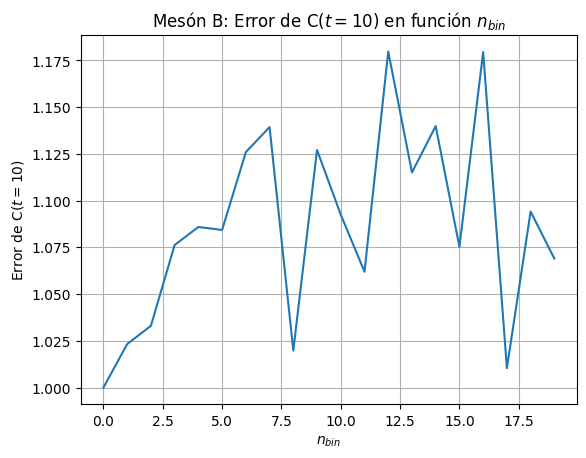

In [ ]:
Nplat = 20
rango = np.linspace(0, Nplat-1, Nplat)
plateau_B = error_corrB_t10[: Nplat]

plt.plot(rango, plateau_B)

plt.xlabel('$n_{bin}$')
plt.ylabel('Error de C($t=10$)')
plt.title('Mesón B: Error de C($t=10$) en función $n_{bin}$')
plt.grid(True)
plt.show()

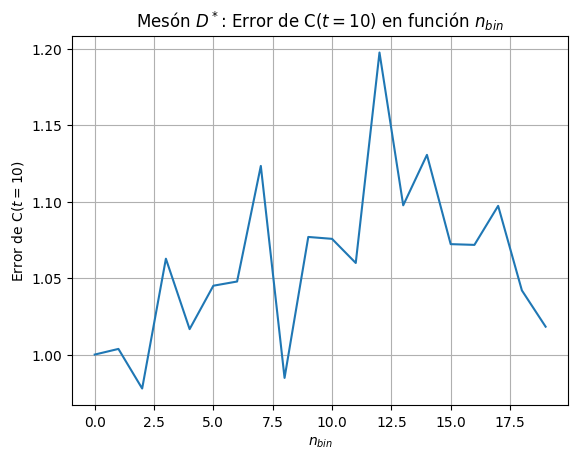

In [ ]:
plateau_D = error_corrD_t10[: Nplat]
plt.plot(rango, plateau_D)

plt.xlabel('$n_{bin}$')
plt.ylabel('Error de C($t=10$)')
plt.title('Mesón $D^*$: Error de C($t=10$) en función $n_{bin}$')
plt.grid(True)
plt.show()

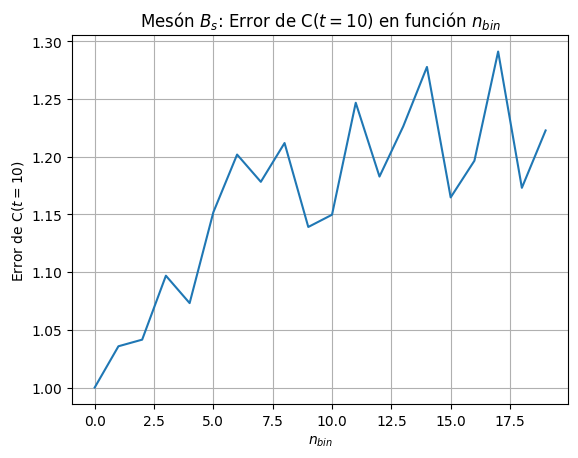

In [ ]:
plateau_B_s = error_corrB_s_t10[: Nplat]
plt.plot(rango, plateau_B_s)

plt.xlabel('$n_{bin}$')
plt.ylabel('Error de C($t=10$) ')
plt.title('Mesón $B_s$: Error de C($t=10$) en función $n_{bin}$')
plt.grid(True)
plt.show()

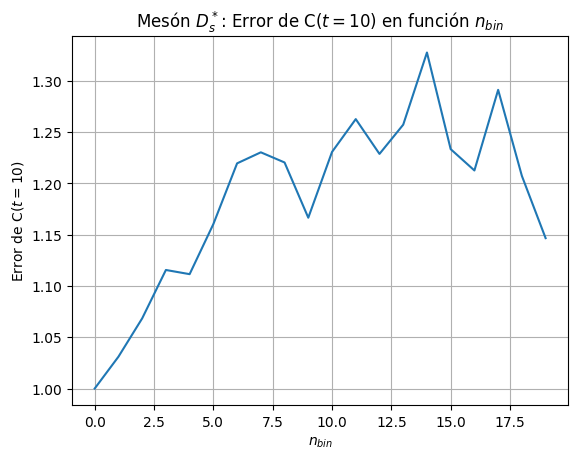

In [ ]:

plateau_D_s = error_corrD_s_t10[: Nplat]
plt.plot(rango, plateau_D_s)

plt.xlabel('$n_{bin}$')
plt.ylabel('Error de C($t=10$)')
plt.title('Mesón $D_s^*$: Error de C($t=10$) en función $n_{bin}$')
plt.grid(True)
plt.show()

Podemos observar que para un tamaño de binning de entre 10 y 13 se alcanza un plateau. A pesar de que la forma no sea estrictamente rigurosa, la variación entre un tamaño y otro no altera el hecho de que con este tamaño ya no subestimamos las incertidumbres sobre nuestros datos, por lo que elegimos de tamaño $B=11$ y a partir de ahora trabajaremos todo el programa con este tamaño.

<h2> 3. FUNCIONES DE CORRELACIÓN A 3 PUNTOS</h2>

<br>

Hasta ahora solo hemos trabajado con funciones de correlación a 2 puntos: una partícula se crea en un punto y tiempo y se aniquila en otro punto y otro tiempo. Realmente, a nosotros nos interesan las funciones a 3 puntos que describen procesos en los que hay una interacción entre la creación y la aniquilación de la partícula. Se resume en: una partícula se crea en un punto y tiempo, interacciona en otro punto y tiempo, en nuestro caso a través de la interacción débil, desintegrándose en otra partícula nueva o no y esta se aniquila en un punto y tiempo finales.

Estas funciones nos interesan para poder obtener los elementos de matriz con los que podemos calcular $h_{A_1}(\omega = 1)$, relacionados a través de la siguiente expresión para el caso de la transición $B^+ \longrightarrow \bar{D^*}^0 + l^+ + \nu_l$:
$$
\frac{\langle D^* | A^k | B \rangle \ \langle B | A^k | D^* \rangle}{\langle D^* | V^4 | D^* \rangle \ \langle B | V^4 | B \rangle}=|h_{A_1}(1)|^2
\tag{2}
$$
Donde ambos mesones inicial y final se encuentran en reposo, y la polarización del mesón $D^*$ solo tiene componentes espaciales. Las corrientes $A^k$ son las componentes espaciales de la corriente débil axial $A^{\mu}$, mientras que la corriente $V^4$ es la componente temporal de la corriente débil vectorial $V^{\mu}$. La expresión es análoga para el caso de las partículas $B_s$ y $D_s^*$, que siguen la misma transición pero el quark espectante es un quark $\textbf{strange (s)}$ en lugar de un quark $\textbf{up (u)}$.

Las expresiones que toman las funciones de correlación a 3 puntos son las siguientes:
$$
C_{3\ pt}(t,\ T) = \sum_{j,\ k} \frac{1}{2\ E_j}\ \frac{1}{2\ E_k} \sqrt{Z_j^{O_1}} e^{-E_j \ t} \langle j | A^{\mu}(t) | k \rangle \sqrt{Z_k^{O_2}} \ e^{-E_k \ (T-t)}
$$

Donde $j, \ k$ hacen referencia a los distintos estados de las partículas (en nuestro caso serán estados mesónicos, como $B$ y $D^*$), $Z_m^{O_n} = |\langle O_n|m \rangle|^2 $ es el factor de overlap del operador de creación o aniquilación $O_n$ con el estado mesónico $m$, $E_m$ la energía del estado $m$ y $\langle j | A^k | k \rangle$ el elemento de matriz de la transición, que es lo que queremos obtener.

Vamos a leer dichas funciones de correlación a 3 puntos con los nuevos correladores que describen las interacciones de interés. Posteriormente, realizaremos el cociente $R(t,\ T)$ de las funciones de correlación que contienen los elementos de matriz que aparecen en la expresión $(2)$ y, tras el correspondiente ajuste, obtendremos $h_{A_1}(1)$.

En la simulación, hay dos posibles formas de crear las partículas: nuestra "fuente" de partículas puede crearlas utilizando dos formas de $\textbf{smearing}$, que consiste en suavizar o difuminar el campo de los quarks que forman nuestros mesones, de manera que dichos quarks dejan de ser partículas puntuales y pasan a ocupar una pequeña región de nuestro lattice. Esto se hace para mejorar el acoplamiento a los estados físicos que buscamos (podemos buscar el estado fundamental de un mesón o un estado excitado cualquiera).

El método de smearing $1S$ consiste en realizar una difuminación de forma que el campo del quark se extienda a lo largo de una región del espacio que siga una distribución parecida a la función de onda 1S del estado fundamental, es decir:
$$
\Psi_{1S} \sim e^{-r/r_0}
$$

En método de smearing $RW$ se utiliza un $\text{random walk}$ para extender el campo de los quarks a sus posiciones vecinas.

Los "sumideros", o puntos donde se aniquilan las partículas, solo presentan el método $1S$ de smearing, por lo que solo tendremos en cuenta este tipo de smearing para leer las funciones de correlación y posteriores cálculos.
<br>

En esta parte, vamos a obtener las funciones de correlación correspondientes a cada método de smearing, calcularemos los cocientes $R(t,\ T)$ también para cada tipo de smearing y realizaremos un ajuste conjunto para ambos cocientes. Comenzamos con el smearing $1S$. Hemos de añadir que para obtener la función de correlación correspondiente a la transición $\langle B | A^k | D^* \rangle$, invertimos temporalmente la función correspondiente a $\langle D^* | A^k | B \rangle$ por comodidad en los cálculos, ya que esto hará que se nos eliminen los factores de overlap correspondientes a XXXXXXXXXXX y el ajuste que realicemos posteriormente sea más cómodo de realizar y preciso.

In [ ]:
# Obtenemos las funciones de correlacion de 3pt para obtener los cocientes y hA1(1)
T1 = 12
binsize = 11
L_conf = math.ceil(N_conf/binsize)

# Comenzamos con los elementos <D*|A_X|B>
D1_A1_B_T12_1S_temp = np.array (myFile['data']["P5_A1_V1_T12_k0.08574_RW_1S_rot_rot_m0.00507_k0.12201_p000"])
D2_A2_B_T12_1S_temp = np.array (myFile['data']["P5_A2_V2_T12_k0.08574_RW_1S_rot_rot_m0.00507_k0.12201_p000"])
D3_A3_B_T12_1S_temp = np.array (myFile['data']["P5_A3_V3_T12_k0.08574_RW_1S_rot_rot_m0.00507_k0.12201_p000"])


# Encontramos los elementos <B|A_X|D*> a partir de la inversion temporal t-->T-t de los <D*|A_X|B>
B_A1_D1_T12_1S_temp = np.zeros((N_conf, T1+1))
B_A2_D2_T12_1S_temp = np.zeros((N_conf, T1+1))
B_A3_D3_T12_1S_temp = np.zeros((N_conf, T1+1))

for t in range(T1+1):
    B_A1_D1_T12_1S_temp [:, t] = D1_A1_B_T12_1S_temp[:, T1-t]
    B_A2_D2_T12_1S_temp [:, t] = D2_A2_B_T12_1S_temp[:, T1-t]
    B_A3_D3_T12_1S_temp [:, t] = D3_A3_B_T12_1S_temp[:, T1-t]


# Elemento <D*|V_4|D*>
D1_V4_D1_T12_1S_temp = np.array (myFile['data']["V1_V4_V1_T12_k0.12201_RW_1S_rot_rot_m0.00507_k0.12201_p000"])

# Elemento <B|V_4|B>
B_V4_B_T12_1S_temp = np.array (myFile['data']["P5_V4_P5_T12_k0.08574_RW_1S_rot_rot_m0.00507_k0.08574_p000"])


# Realizamos un binning + jackknife de las funciones de correlación obtenidas:
D1_A1_B_T12_1S = mean_cov_jackk(D1_A1_B_T12_1S_temp, binsize, cov_matrix = False)
D2_A2_B_T12_1S = mean_cov_jackk(D2_A2_B_T12_1S_temp, binsize, cov_matrix = False)
D3_A3_B_T12_1S = mean_cov_jackk(D3_A3_B_T12_1S_temp, binsize, cov_matrix = False)

B_A1_D1_T12_1S = mean_cov_jackk(B_A1_D1_T12_1S_temp, binsize, cov_matrix = False)
B_A2_D2_T12_1S = mean_cov_jackk(B_A2_D2_T12_1S_temp, binsize, cov_matrix = False)
B_A3_D3_T12_1S = mean_cov_jackk(B_A3_D3_T12_1S_temp, binsize, cov_matrix = False)

D1_V4_D1_T12_1S = mean_cov_jackk(D1_V4_D1_T12_1S_temp, binsize, cov_matrix = False)

B_V4_B_T12_1S = mean_cov_jackk(B_V4_B_T12_1S_temp, binsize, cov_matrix = False)


num1 = D1_A1_B_T12_1S[:, : (T1+1)]*B_A1_D1_T12_1S + D2_A2_B_T12_1S[:, : (T1+1)]*B_A2_D2_T12_1S + D3_A3_B_T12_1S[:, :T1+1]*B_A3_D3_T12_1S
den1 = D1_V4_D1_T12_1S[:, : (T1+1)]*B_V4_B_T12_1S[:, :T1+1]

R_T12_1S = (1/3)*(num1/den1)
cov_R_T12_1S = covJackk(R_T12_1S)

a1 = np.mean(R_T12_1S, 0)

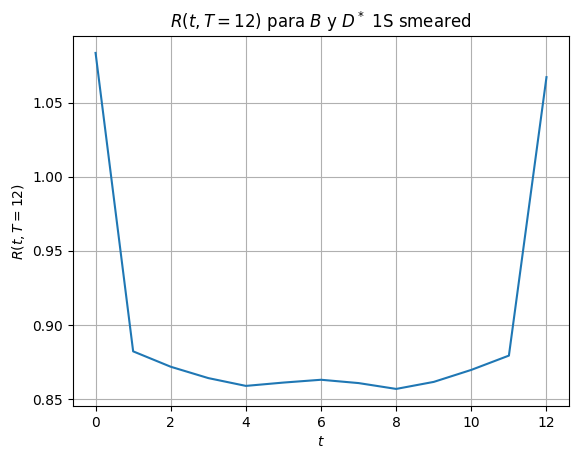

In [ ]:
rT1 = np.linspace(0, T1, T1+1)
plt.plot(rT1, a1)

plt.xlabel('$t$')
plt.ylabel('$R(t, T=12)$')
plt.title('$R(t, T=12)$ para $B$ y $D^*$ 1S smeared')
plt.grid(True)
plt.show()

In [ ]:
# Repetimos el proceso idénticamente con T = 13
T2 = 13

D1_A1_B_T13_1S_temp = np.array (myFile['data']["P5_A1_V1_T13_k0.08574_RW_1S_rot_rot_m0.00507_k0.12201_p000"])
D2_A2_B_T13_1S_temp = np.array (myFile['data']["P5_A2_V2_T13_k0.08574_RW_1S_rot_rot_m0.00507_k0.12201_p000"])
D3_A3_B_T13_1S_temp = np.array (myFile['data']["P5_A3_V3_T13_k0.08574_RW_1S_rot_rot_m0.00507_k0.12201_p000"])


B_A1_D1_T13_1S_temp = np.zeros((N_conf, T2+1))
B_A2_D2_T13_1S_temp = np.zeros((N_conf, T2+1))
B_A3_D3_T13_1S_temp = np.zeros((N_conf, T2+1))

for t in range(T2+1):
    B_A1_D1_T13_1S_temp [:, t] = D1_A1_B_T13_1S_temp[:, T2-t]
    B_A2_D2_T13_1S_temp [:, t] = D2_A2_B_T13_1S_temp[:, T2-t]
    B_A3_D3_T13_1S_temp [:, t] = D3_A3_B_T13_1S_temp[:, T2-t]


D1_V4_D1_T13_1S_temp = np.array (myFile['data']["V1_V4_V1_T13_k0.12201_RW_1S_rot_rot_m0.00507_k0.12201_p000"])

B_V4_B_T13_1S_temp = np.array (myFile['data']["P5_V4_P5_T13_k0.08574_RW_1S_rot_rot_m0.00507_k0.08574_p000"])


D1_A1_B_T13_1S = mean_cov_jackk(D1_A1_B_T13_1S_temp, binsize, cov_matrix = False)
D2_A2_B_T13_1S = mean_cov_jackk(D2_A2_B_T13_1S_temp, binsize, cov_matrix = False)
D3_A3_B_T13_1S = mean_cov_jackk(D3_A3_B_T13_1S_temp, binsize, cov_matrix = False)

B_A1_D1_T13_1S = mean_cov_jackk(B_A1_D1_T13_1S_temp, binsize, cov_matrix = False)
B_A2_D2_T13_1S = mean_cov_jackk(B_A2_D2_T13_1S_temp, binsize, cov_matrix = False)
B_A3_D3_T13_1S = mean_cov_jackk(B_A3_D3_T13_1S_temp, binsize, cov_matrix = False)

D1_V4_D1_T13_1S = mean_cov_jackk(D1_V4_D1_T13_1S_temp, binsize, cov_matrix = False)

B_V4_B_T13_1S = mean_cov_jackk(B_V4_B_T13_1S_temp, binsize, cov_matrix = False)


num2 = D1_A1_B_T13_1S[:, : T2+1]*B_A1_D1_T13_1S + D2_A2_B_T13_1S[:, : T2+1]*B_A2_D2_T13_1S + D3_A3_B_T13_1S[:, : T2+1]*B_A3_D3_T13_1S
den2 = D1_V4_D1_T13_1S[:, : T2+1]*B_V4_B_T13_1S[:, : T2+1]

R_T13_1S = (1/3)*(num2/den2)

cov_R_T13_1S = covJackk(R_T13_1S)

a2 = np.mean(R_T13_1S, 0)

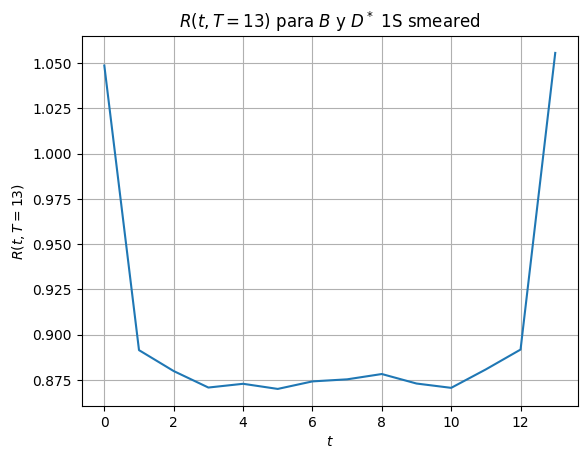

In [ ]:
rT2 = np.linspace(0, T2, T2+1)
plt.plot(rT2, a2)

plt.xlabel('$t$')
plt.ylabel('$R(t, T=13)$')
plt.title('$R(t, T=13)$ para $B$ y $D^*$ 1S smeared')
plt.grid(True)
plt.show()

In [ ]:

# Ahora lo calculamos para el caso de los mesones con quark strange Ds* y Bs
D1_A1_B_T12_1S_s_temp = np.array (myFile['data']["P5_A1_V1_T12_k0.08574_RW_1S_rot_rot_m0.0507_k0.12201_p000"])
D2_A2_B_T12_1S_s_temp = np.array (myFile['data']["P5_A2_V2_T12_k0.08574_RW_1S_rot_rot_m0.0507_k0.12201_p000"])
D3_A3_B_T12_1S_s_temp = np.array (myFile['data']["P5_A3_V3_T12_k0.08574_RW_1S_rot_rot_m0.0507_k0.12201_p000"])


# Encontramos los elementos <B|A_X|D*> a partir de la inversion temporal t-->T-t de los <D*|A_X|B>
B_A1_D1_T12_1S_s_temp = np.zeros((N_conf, T1+1))
B_A2_D2_T12_1S_s_temp = np.zeros((N_conf, T1+1))
B_A3_D3_T12_1S_s_temp = np.zeros((N_conf, T1+1))

for t in range(T1+1):
    B_A1_D1_T12_1S_s_temp [:, t] = D1_A1_B_T12_1S_s_temp[:, T1-t]
    B_A2_D2_T12_1S_s_temp [:, t] = D2_A2_B_T12_1S_s_temp[:, T1-t]
    B_A3_D3_T12_1S_s_temp [:, t] = D3_A3_B_T12_1S_s_temp[:, T1-t]


# Elemento <D*|V_4|D*>
D1_V4_D1_T12_1S_s_temp = np.array (myFile['data']["V1_V4_V1_T12_k0.12201_RW_1S_rot_rot_m0.0507_k0.12201_p000"])

# Elemento <B|V_4|B>
B_V4_B_T12_1S_s_temp = np.array (myFile['data']["P5_V4_P5_T12_k0.08574_RW_1S_rot_rot_m0.0507_k0.08574_p000"])


D1_A1_B_T12_1S_s = mean_cov_jackk(D1_A1_B_T12_1S_s_temp, binsize, cov_matrix = False)
D2_A2_B_T12_1S_s = mean_cov_jackk(D2_A2_B_T12_1S_s_temp, binsize, cov_matrix = False)
D3_A3_B_T12_1S_s = mean_cov_jackk(D3_A3_B_T12_1S_s_temp, binsize, cov_matrix = False)

B_A1_D1_T12_1S_s = mean_cov_jackk(B_A1_D1_T12_1S_s_temp, binsize, cov_matrix = False)
B_A2_D2_T12_1S_s = mean_cov_jackk(B_A2_D2_T12_1S_s_temp, binsize, cov_matrix = False)
B_A3_D3_T12_1S_s = mean_cov_jackk(B_A3_D3_T12_1S_s_temp, binsize, cov_matrix = False)

D1_V4_D1_T12_1S_s = mean_cov_jackk(D1_V4_D1_T12_1S_s_temp, binsize, cov_matrix = False)

B_V4_B_T12_1S_s = mean_cov_jackk(B_V4_B_T12_1S_s_temp, binsize, cov_matrix = False)


num3 = D1_A1_B_T12_1S_s[:, : T1+1]*B_A1_D1_T12_1S_s + D2_A2_B_T12_1S_s[:, : T1+1]*B_A2_D2_T12_1S_s + D3_A3_B_T12_1S_s[:, : T1+1]*B_A3_D3_T12_1S_s
den3 = D1_V4_D1_T12_1S_s[:, : T1+1]*B_V4_B_T12_1S_s[:, : T1+1]

R_T12_1S_s = (1/3)*(num3/den3)
cov_R_T12_1S_s = covJackk(R_T12_1S_s)

a3 = np.mean(R_T12_1S_s, 0)

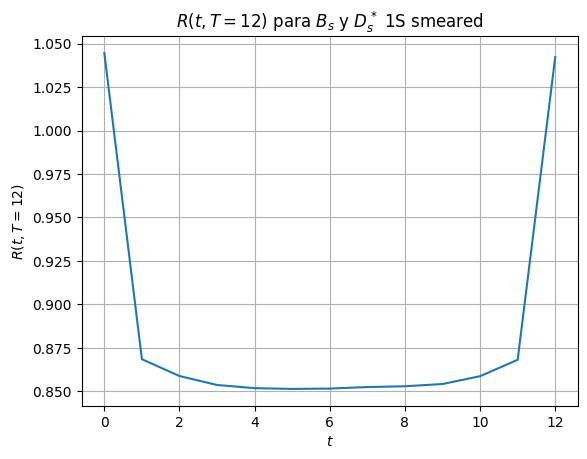

In [ ]:
plt.plot(rT1, a3)

plt.xlabel('$t$')
plt.ylabel('$R(t, T=12)$')
plt.title('$R(t, T=12)$ para $B_s$ y $D^*_s$ 1S smeared')
plt.grid(True)
plt.show()

In [ ]:
D1_A1_B_T13_1S_s_temp = np.array (myFile['data']["P5_A1_V1_T13_k0.08574_RW_1S_rot_rot_m0.0507_k0.12201_p000"])
D2_A2_B_T13_1S_s_temp = np.array (myFile['data']["P5_A2_V2_T13_k0.08574_RW_1S_rot_rot_m0.0507_k0.12201_p000"])
D3_A3_B_T13_1S_s_temp = np.array (myFile['data']["P5_A3_V3_T13_k0.08574_RW_1S_rot_rot_m0.0507_k0.12201_p000"])


B_A1_D1_T13_1S_s_temp = np.zeros((N_conf, T2+1))
B_A2_D2_T13_1S_s_temp = np.zeros((N_conf, T2+1))
B_A3_D3_T13_1S_s_temp = np.zeros((N_conf, T2+1))

for t in range(T2+1):
    B_A1_D1_T13_1S_s_temp [:, t] = D1_A1_B_T13_1S_s_temp[:, T2-t]
    B_A2_D2_T13_1S_s_temp [:, t] = D2_A2_B_T13_1S_s_temp[:, T2-t]
    B_A3_D3_T13_1S_s_temp [:, t] = D3_A3_B_T13_1S_s_temp[:, T2-t]


D1_V4_D1_T13_1S_s_temp = np.array (myFile['data']["V1_V4_V1_T13_k0.12201_RW_1S_rot_rot_m0.0507_k0.12201_p000"])

B_V4_B_T13_1S_s_temp = np.array (myFile['data']["P5_V4_P5_T13_k0.08574_RW_1S_rot_rot_m0.0507_k0.08574_p000"])


D1_A1_B_T13_1S_s = mean_cov_jackk(D1_A1_B_T13_1S_s_temp, binsize, cov_matrix = False)
D2_A2_B_T13_1S_s = mean_cov_jackk(D2_A2_B_T13_1S_s_temp, binsize, cov_matrix = False)
D3_A3_B_T13_1S_s = mean_cov_jackk(D3_A3_B_T13_1S_s_temp, binsize, cov_matrix = False)

B_A1_D1_T13_1S_s = mean_cov_jackk(B_A1_D1_T13_1S_s_temp, binsize, cov_matrix = False)
B_A2_D2_T13_1S_s = mean_cov_jackk(B_A2_D2_T13_1S_s_temp, binsize, cov_matrix = False)
B_A3_D3_T13_1S_s = mean_cov_jackk(B_A3_D3_T13_1S_s_temp, binsize, cov_matrix = False)

D1_V4_D1_T13_1S_s = mean_cov_jackk(D1_V4_D1_T13_1S_s_temp, binsize, cov_matrix = False)

B_V4_B_T13_1S_s = mean_cov_jackk(B_V4_B_T13_1S_s_temp, binsize, cov_matrix = False)


num4 = D1_A1_B_T13_1S_s[:, : T2+1]*B_A1_D1_T13_1S_s + D2_A2_B_T13_1S_s[:, : T2+1]*B_A2_D2_T13_1S_s + D3_A3_B_T13_1S_s[:, : T2+1]*B_A3_D3_T13_1S_s
den4 = D1_V4_D1_T13_1S_s[:, : T2+1]*B_V4_B_T13_1S_s[:, : T2+1]

R_T13_1S_s = (1/3)*(num4/den4)

cov_R_T13_1S_s = covJackk(R_T13_1S_s)

a4 = np.mean(R_T13_1S_s, 0)


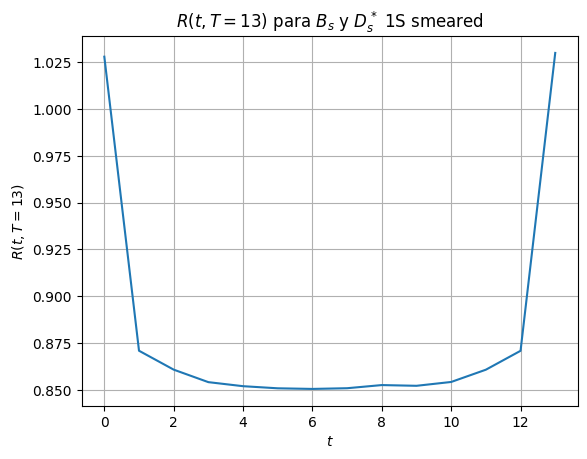

In [ ]:
plt.plot(rT2, a4)

plt.xlabel('$t$')
plt.ylabel('$R(t, T=13)$')
plt.title('$R(t, T=13)$ para $B_s$ y $D^*_s$ 1S smeared')
plt.grid(True)
plt.show()

In [ ]:
# Ahora aplicamos la ecuacion 21 para reducir las oscilaciones

R1_1S = np.zeros((L_conf, T1+1))
R1_1S_s = np.zeros((L_conf, T1+1))

for t in range(T1+1):
    R1_1S[:, t] = 0.5*R_T12_1S[:, t]+0.25*(R_T13_1S[:, t]+R_T13_1S[:, t+1])
    R1_1S_s[:, t] = 0.5*R_T12_1S_s[:, t]+0.25*(R_T13_1S_s[:, t]+R_T13_1S_s[:, t+1])


cov_R1_1S = covJackk(R1_1S)
cov_R1_1S_s = covJackk(R1_1S_s)

a5 = np.mean(R1_1S, 0)
a6 = np.mean(R1_1S_s, 0)

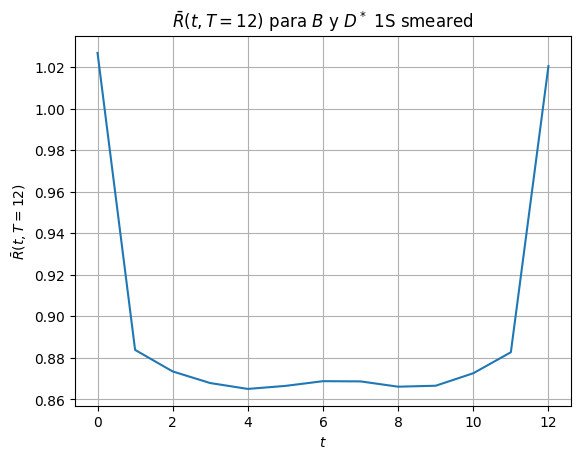

In [ ]:
rosc = np.linspace(0, T1, T1+1)
plt.plot(rosc, a5)

plt.xlabel('$t$')
plt.ylabel(r'$\bar{R}(t, T=12)$')
plt.title(r'$\bar{R}(t, T=12)$ para $B$ y $D^*$ 1S smeared')
plt.grid(True)
plt.show()

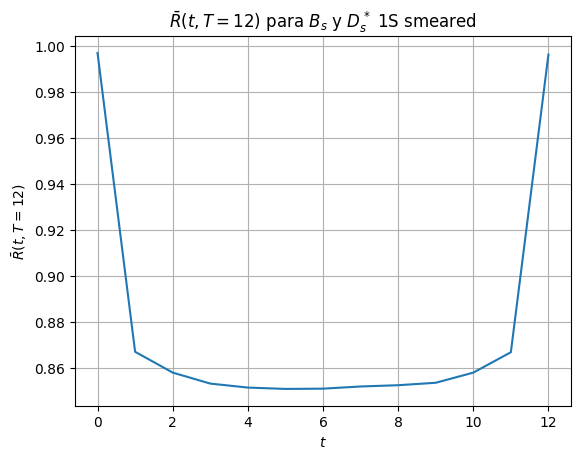

In [ ]:
plt.plot(rosc, a6)

plt.xlabel('$t$')
plt.ylabel(r'$\bar{R}(t, T=12)$')
plt.title(r'$\bar{R}(t, T=12)$ para $B_s$ y $D^*_s$ 1S smeared')
plt.grid(True)
plt.show()

In [ ]:
## REPETIMOS TODO PARA EL OTRO TIPO DE SMEARING

# Comenzamos con los elementos <D*|A_X|B>
D1_A1_B_T12_RW_temp = np.array (myFile['data']["P5_A1_V1_T12_k0.08574_RW_RW_rot_rot_m0.00507_k0.12201_p000"])
D2_A2_B_T12_RW_temp = np.array (myFile['data']["P5_A2_V2_T12_k0.08574_RW_RW_rot_rot_m0.00507_k0.12201_p000"])
D3_A3_B_T12_RW_temp = np.array (myFile['data']["P5_A3_V3_T12_k0.08574_RW_RW_rot_rot_m0.00507_k0.12201_p000"])

# Elemento <D*|V_4|D*>
D1_V4_D1_T12_RW_temp = np.array (myFile['data']["V1_V4_V1_T12_k0.12201_RW_RW_rot_rot_m0.00507_k0.12201_p000"])

D1_A1_B_T12_RW = mean_cov_jackk(D1_A1_B_T12_RW_temp, binsize, cov_matrix = False)
D2_A2_B_T12_RW = mean_cov_jackk(D2_A2_B_T12_RW_temp, binsize, cov_matrix = False)
D3_A3_B_T12_RW = mean_cov_jackk(D3_A3_B_T12_RW_temp, binsize, cov_matrix = False)

D1_V4_D1_T12_RW = mean_cov_jackk(D1_V4_D1_T12_RW_temp, binsize, cov_matrix = False)

num5 = D1_A1_B_T12_RW[:, : T1+1]*B_A1_D1_T12_1S + D2_A2_B_T12_RW[:, : T1+1]*B_A2_D2_T12_1S + D3_A3_B_T12_RW[:, : T1+1]*B_A3_D3_T12_1S
den5 = D1_V4_D1_T12_RW[:, : T1+1]*B_V4_B_T12_1S[:, : T1+1]

R_T12_RW = (1/3)*(num5/den5)

cov_R_T12_RW = covJackk(R_T12_RW)

a7 = np.mean(R_T12_RW, 0)


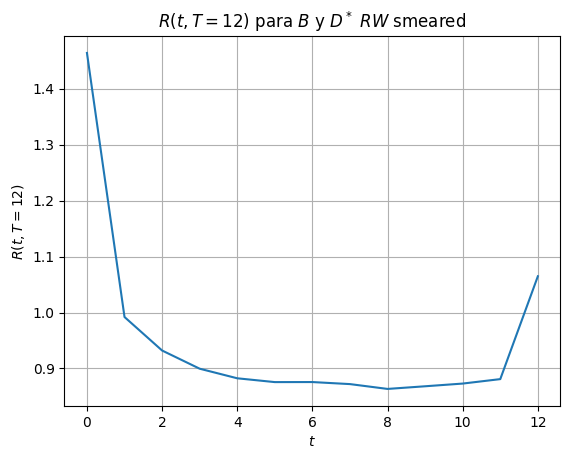

In [ ]:
plt.plot(rT1, a7)

plt.xlabel('$t$')
plt.ylabel('$R(t, T=12)$')
plt.title('$R(t, T=12)$ para $B$ y $D^*$ $RW$ smeared')
plt.grid(True)
plt.show()

In [ ]:
# Repetimos el proceso idénticamente con T = 13

D1_A1_B_T13_RW_temp = np.array (myFile['data']["P5_A1_V1_T13_k0.08574_RW_RW_rot_rot_m0.00507_k0.12201_p000"])
D2_A2_B_T13_RW_temp = np.array (myFile['data']["P5_A2_V2_T13_k0.08574_RW_RW_rot_rot_m0.00507_k0.12201_p000"])
D3_A3_B_T13_RW_temp = np.array (myFile['data']["P5_A3_V3_T13_k0.08574_RW_RW_rot_rot_m0.00507_k0.12201_p000"])

# Elemento <D*|V_4|D*>
D1_V4_D1_T13_RW_temp = np.array (myFile['data']["V1_V4_V1_T13_k0.12201_RW_RW_rot_rot_m0.00507_k0.12201_p000"])

#Realizamos binning y jackknife
D1_A1_B_T13_RW = mean_cov_jackk(D1_A1_B_T13_RW_temp, binsize, cov_matrix = False)
D2_A2_B_T13_RW = mean_cov_jackk(D2_A2_B_T13_RW_temp, binsize, cov_matrix = False)
D3_A3_B_T13_RW = mean_cov_jackk(D3_A3_B_T13_RW_temp, binsize, cov_matrix = False)

D1_V4_D1_T13_RW = mean_cov_jackk(D1_V4_D1_T13_RW_temp, binsize, cov_matrix = False)

num6= D1_A1_B_T13_RW[:, : T2+1]*B_A1_D1_T13_1S + D2_A2_B_T13_RW[:, : T2+1]*B_A2_D2_T13_1S + D3_A3_B_T13_RW[:, : T2+1]*B_A3_D3_T13_1S
den6 = D1_V4_D1_T13_RW[:, : T2+1]*B_V4_B_T13_1S[:, : T2+1]

R_T13_RW = (1/3)*(num6/den6)
cov_R_T13_RW = covJackk(R_T13_RW)

a8 = np.mean(R_T13_RW, 0)

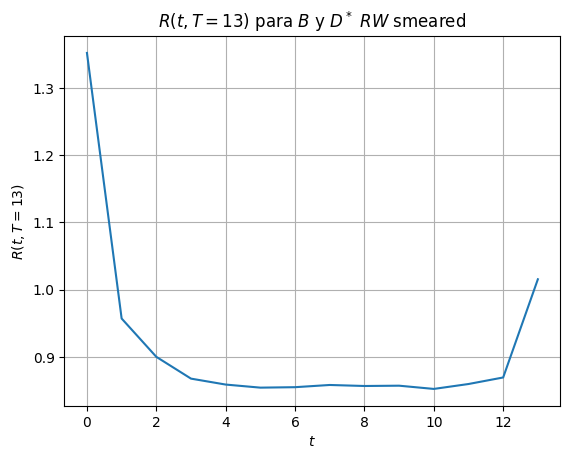

In [ ]:
plt.plot(rT2, a8)

plt.xlabel('$t$')
plt.ylabel('$R(t, T=13)$')
plt.title('$R(t, T=13)$ para $B$ y $D^*$ $RW$ smeared')
plt.grid(True)
plt.show()

In [ ]:
D1_A1_B_T12_RW_s_temp = np.array (myFile['data']["P5_A1_V1_T12_k0.08574_RW_RW_rot_rot_m0.0507_k0.12201_p000"])
D2_A2_B_T12_RW_s_temp = np.array (myFile['data']["P5_A2_V2_T12_k0.08574_RW_RW_rot_rot_m0.0507_k0.12201_p000"])
D3_A3_B_T12_RW_s_temp = np.array (myFile['data']["P5_A3_V3_T12_k0.08574_RW_RW_rot_rot_m0.0507_k0.12201_p000"])

# Elemento <D*|V_4|D*>
D1_V4_D1_T12_RW_s_temp = np.array (myFile['data']["V1_V4_V1_T12_k0.12201_RW_RW_rot_rot_m0.0507_k0.12201_p000"])

#Realizamos binning y jackknife

D1_A1_B_T12_RW_s = mean_cov_jackk(D1_A1_B_T12_RW_s_temp, binsize, cov_matrix = False)
D2_A2_B_T12_RW_s = mean_cov_jackk(D2_A2_B_T12_RW_s_temp, binsize, cov_matrix = False)
D3_A3_B_T12_RW_s = mean_cov_jackk(D3_A3_B_T12_RW_s_temp, binsize, cov_matrix = False)

D1_V4_D1_T12_RW_s = mean_cov_jackk(D1_V4_D1_T12_RW_s_temp, binsize, cov_matrix = False)

num7 = D1_A1_B_T12_RW_s[:, : T1+1]*B_A1_D1_T12_1S_s + D2_A2_B_T12_RW_s[:, : T1+1]*B_A2_D2_T12_1S_s + D3_A3_B_T12_RW_s[:, : T1+1]*B_A3_D3_T12_1S_s
den7 = D1_V4_D1_T12_RW_s[:, : T1+1]*B_V4_B_T12_1S_s[:, : T1+1]

R_T12_RW_s = (1/3)*(num7/den7)
cov_R_T12_RW_s = covJackk(R_T12_RW_s)

a9 = np.mean(R_T12_RW_s, 0)

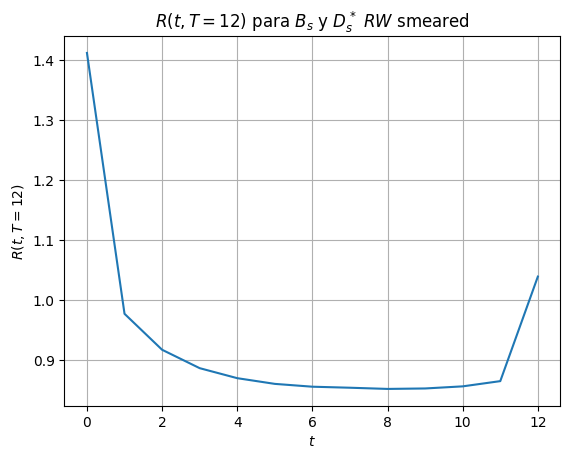

In [ ]:
plt.plot(rT1, a9)

plt.xlabel('$t$')
plt.ylabel('$R(t, T=12)$')
plt.title('$R(t, T=12)$ para $B_s$ y $D^*_s$ $RW$ smeared')
plt.grid(True)
plt.show()

In [ ]:
D1_A1_B_T13_RW_s_temp = np.array (myFile['data']["P5_A1_V1_T13_k0.08574_RW_RW_rot_rot_m0.0507_k0.12201_p000"])
D2_A2_B_T13_RW_s_temp = np.array (myFile['data']["P5_A2_V2_T13_k0.08574_RW_RW_rot_rot_m0.0507_k0.12201_p000"])
D3_A3_B_T13_RW_s_temp = np.array (myFile['data']["P5_A3_V3_T13_k0.08574_RW_RW_rot_rot_m0.0507_k0.12201_p000"])

# Elemento <D*|V_4|D*>
D1_V4_D1_T13_RW_s_temp = np.array (myFile['data']["V1_V4_V1_T13_k0.12201_RW_RW_rot_rot_m0.0507_k0.12201_p000"])

# Realizamos binning y jackknife
D1_A1_B_T13_RW_s = mean_cov_jackk(D1_A1_B_T13_RW_s_temp, binsize, cov_matrix = False)
D2_A2_B_T13_RW_s = mean_cov_jackk(D2_A2_B_T13_RW_s_temp, binsize, cov_matrix = False)
D3_A3_B_T13_RW_s = mean_cov_jackk(D3_A3_B_T13_RW_s_temp, binsize, cov_matrix = False)

D1_V4_D1_T13_RW_s = mean_cov_jackk(D1_V4_D1_T13_RW_s_temp, binsize, cov_matrix = False)

num8 = D1_A1_B_T13_RW_s[:, : T2+1]*B_A1_D1_T13_1S_s + D2_A2_B_T13_RW_s[:, : T2+1]*B_A2_D2_T13_1S_s + D3_A3_B_T13_RW_s[:, : T2+1]*B_A3_D3_T13_1S_s
den8 = D1_V4_D1_T13_RW_s[:, : T2+1]*B_V4_B_T13_1S_s[:, : T2+1]

R_T13_RW_s = (1/3)*(num8/den8)
cov_R_T13_RW_s = covJackk(R_T13_RW_s)

a10 = np.mean(R_T13_RW_s, 0)

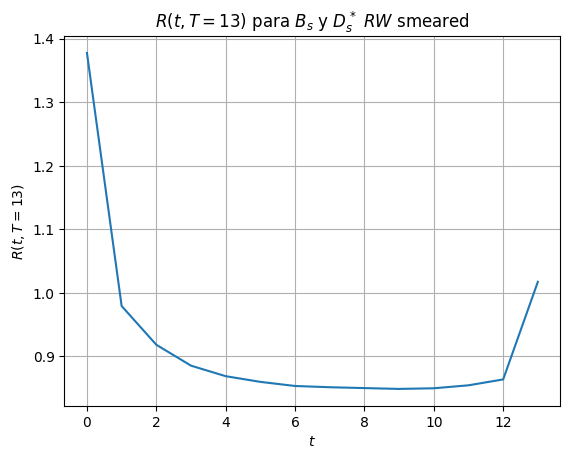

In [ ]:
plt.plot(rT2, a10)

plt.xlabel('$t$')
plt.ylabel('$R(t, T=13)$')
plt.title('$R(t, T=13)$ para $B_s$ y $D^*_s$ $RW$ smeared')
plt.grid(True)
plt.show()

In [ ]:
# Ahora aplicamos la ecuacion 21 para reducir las oscilaciones

R1_RW = np.zeros((L_conf, T1+1))
R1_RW_s = np.zeros((L_conf, T1+1))

for t in range(T1+1):
    R1_RW[:, t] = 0.5*R_T12_RW[:, t]+0.25*(R_T13_RW[:, t]+R_T13_RW[:, t+1])
    R1_RW_s[:, t] = 0.5*R_T12_RW_s[:, t]+0.25*(R_T13_RW_s[:, t]+R_T13_RW_s[:, t+1])


cov_R1_RW = covJackk(R1_RW)
cov_R1_RW_s = covJackk(R1_RW_s)

a11 = np.mean(R1_RW, 0)
a12 = np.mean(R1_RW_s, 0)

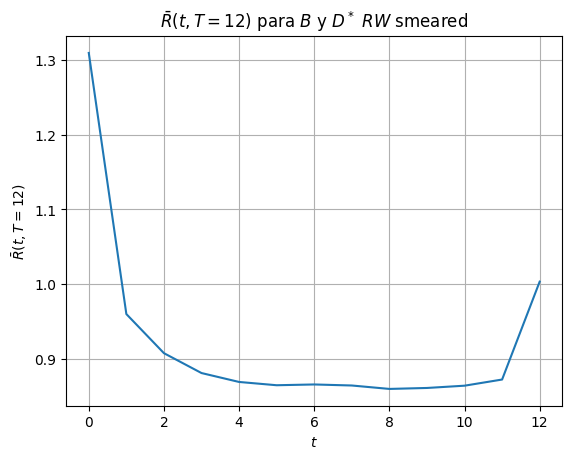

In [ ]:
plt.plot(rosc, a11)

plt.xlabel('$t$')
plt.ylabel(r'$\bar{R}(t, T=12)$')
plt.title(r'$\bar{R}(t, T=12)$ para $B$ y $D^*$ $RW$ smeared')
plt.grid(True)
plt.show()

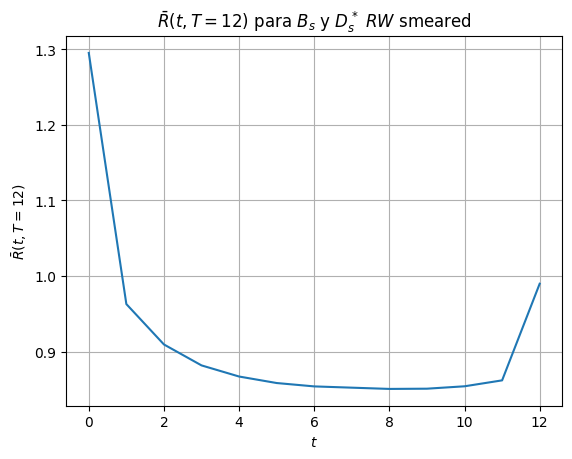

In [ ]:
plt.plot(rosc, a12)

plt.xlabel('$t$')
plt.ylabel(r'$\bar{R}(t, T=12)$')
plt.title(r'$\bar{R}(t, T=12)$ para $B_s$ y $D_s^*$ $RW$ smeared')
plt.grid(True)
plt.show()

In [ ]:
R1 = np.concatenate((R1_1S, R1_RW), axis=1)
R1_s = np.concatenate((R1_1S_s, R1_RW_s), axis=1)

cov_R1 = covJackk(R1)
cov_R1_s = covJackk(R1_s)

a13 = np.mean(R1, 0)
a14 = np.mean(R1_s, 0)


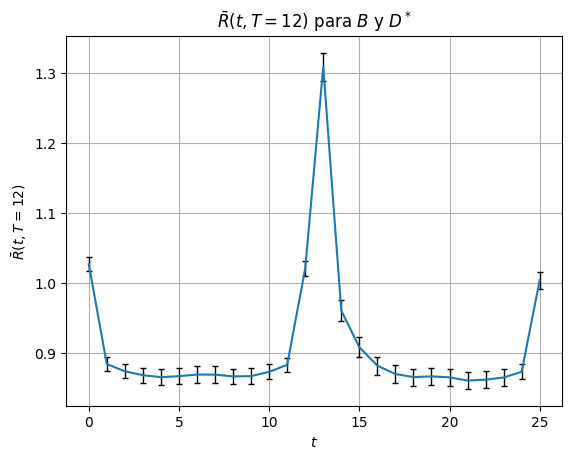

In [ ]:
rconcatenate = np.linspace(0, 2*(T1+1)-1, 2*(T1+1))
errR1 = np.sqrt(cov_R1.diagonal()/L_conf)

plt.errorbar(rconcatenate, a13, errR1, ecolor='k', elinewidth=1, capsize=2)

plt.xlabel('$t$')
plt.ylabel(r'$\bar{R}(t, T=12)$')
plt.title(r'$\bar{R}(t, T=12)$ para $B$ y $D^*$')
plt.grid(True)
plt.show()

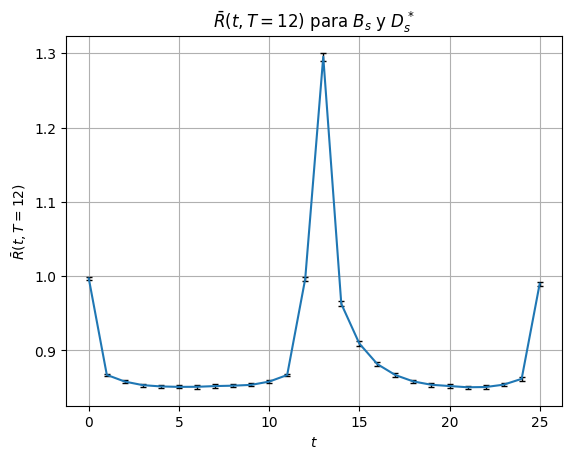

In [ ]:
errR1_s = np.sqrt(cov_R1_s.diagonal()/L_conf)
plt.errorbar(rconcatenate, a14, errR1_s, ecolor='k', elinewidth=1, capsize=2)

plt.xlabel('$t$')
plt.ylabel(r'$\bar{R}(t, T=12)$')
plt.title(r'$\bar{R}(t, T=12)$ para $B_s$ y $D_s^*$')
plt.grid(True)
plt.show()

<h2>4. CÁLCULOS FINALES DE $h_{A_1}(\omega=1)$ Y $|V_{cb}|$</h2>

In [ ]:
# REALIZAMOS EL AJUSTE A f(t)=r[1+A*exp(-E1*t)+B*exp(-E2(T-t))]

import gvar as gv
import lsqfit

E_GeV = 0.5
hbarc = 197.327
a = 0.12
E_lat = 1000*E_GeV*a/hbarc

r_inic_temp = np.array([a5[6], a6[6], a11[6], a12[6]])
r_inic = np.mean(r_inic_temp)

i = 1 #Representa el numero de puntos que quitamos por cada lado
t_data = np.concatenate([np.arange(i, T1+1-i), np.arange(i, T1+1-i)])

def double_fit(t_interv, p):
    mid = len(t_interv) // 2
    t1 = t_interv[:mid]
    t2 = t_interv[mid:]
    #t1 = t_interv[0:T1+1-2*i]
    #t2 = t_interv[T1+1-2*i:2*(T1+1)-4*i]
    r = p['r']
    E = p['E']

    f1 = r*(1 + p['A1']*np.exp(-E*t1) + p['B1']*np.exp(-E*(T1-t1)))
    f2 = r*(1 + p['A2']*np.exp(-E*t2) + p['B2']*np.exp(-E*(T1-t2)))
    return np.concatenate([f1, f2])

v_inic = {
        'r':  gv.gvar(r_inic, 0.25*r_inic),
        'E':  gv.gvar(E_lat, E_lat),
        'A1': gv.gvar(0.0, 1.0),
        'B1': gv.gvar(0.0, 1.0),
        'A2': gv.gvar(0.0, 1.0),
        'B2': gv.gvar(0.0, 1.0),
    }

R1_fit = np.concatenate((R1_1S[:, i:T1+1-i], R1_RW[:, i:T1+1-i]), axis = 1)
R1_s_fit = np.concatenate((R1_1S_s[:, i:T1+1-i], R1_RW_s[:, i:T1+1-i]), axis = 1)

cov_R1_fit = covJackk(R1_fit)
cov_R1_s_fit = covJackk(R1_s_fit)

a13_fit = np.mean(R1_fit, 0)
a14_fit = np.mean(R1_s_fit, 0)

y_R1 = gv.gvar(a13_fit, cov_R1_fit)
fit_R1 = lsqfit.nonlinear_fit(data=(t_data, y_R1), prior=v_inic, fcn=double_fit)
param_R1 = fit_R1.p

y_R1_s = gv.gvar(a14_fit, cov_R1_s_fit)
fit_R1_s = lsqfit.nonlinear_fit(data=(t_data, y_R1_s), prior=v_inic, fcn=double_fit)
param_R1_s = fit_R1_s.p

print(fit_R1)
print(fit_R1_s)

Least Squares Fit:
  chi2/dof [dof] = 0.027 [22]    Q = 1    logGBF = 55.237

Parameters:
              r   0.852 (91)     [  0.86 (21) ]  
              E    0.41 (25)     [  0.30 (30) ]  
             A1   0.049 (95)     [    0 ± 1.0 ]  
             B1   0.046 (92)     [    0 ± 1.0 ]  
             A2    0.23 (19)     [    0 ± 1.0 ]  
             B2    0.04 (10)     [    0 ± 1.0 ]  

Settings:
  svdcut/n = 1e-12/0    tol = (1e-08,1e-10,1e-10*)    (itns/time = 13/0.1s)
  fitter = scipy_least_squares    method = trf

Least Squares Fit:
  chi2/dof [dof] = 0.073 [22]    Q = 1    logGBF = 80.908

Parameters:
              r   0.844 (15)     [  0.86 (21) ]  
              E    0.56 (11)     [  0.30 (30) ]  
             A1   0.042 (18)     [    0 ± 1.0 ]  
             B1   0.042 (16)     [    0 ± 1.0 ]  
             A2   0.249 (37)     [    0 ± 1.0 ]  
             B2   0.038 (18)     [    0 ± 1.0 ]  

Settings:
  svdcut/n = 1e-12/0    tol = (1e-08,1e-10,1e-10*)    (itns/time = 9/0.0s)

In [ ]:
r_R1 = param_R1['r']
err_r_R1 = param_R1['r'].sdev
E_R1 = param_R1['E']
A_R1_1S = param_R1['A1']
B_R1_1S = param_R1['B1']
A_R1_RW = param_R1['A2']
B_R1_RW = param_R1['B2']

r_R1_s = param_R1_s['r']
err_r_R1_s = param_R1_s['r'].sdev
E_R1_s = param_R1_s['E']
A_R1_1S_s = param_R1_s['A1']
B_R1_1S_s = param_R1_s['B1']
A_R1_RW_s = param_R1_s['A2']
B_R1_RW_s = param_R1_s['B2']

In [ ]:
hA1_R1 = np.sqrt(r_R1)
err_hA1_R1 = err_r_R1/(2*hA1_R1)

hA1_R1_s = np.sqrt(r_R1_s)
err_hA1_R1_s = err_r_R1_s/(2*hA1_R1_s)

print('hA1(1) = ',  hA1_R1, "+/-", err_hA1_R1)
print('\nhA1(1) = ',  hA1_R1_s, "+/-", err_hA1_R1_s)

hA1(1) =  0.923(49) +/- 0.0495(27)

hA1(1) =  0.9189(81) +/- 0.008061(71)


In [ ]:
Vcb_F = 0.0360
err_Vcb_F = 0.0005

Vcb_R1 = Vcb_F/hA1_R1
#err_Vcb_R1 = np.sqrt((err_Vcb_F/hA1_R1)**2+(Vcb_F*hA1_R1.sdev/hA1_R1**2)**2)


eta_EW = 1.0066
Vcb_F_eta = 0.03841
err_Vcb_F_eta = 0.00143

Vcb_R1_s = Vcb_F_eta/((hA1_R1_s*eta_EW)**2)
#err_Vcb_R1_s = np.sqrt((err_Vcb_F/hA1_R1_s)**2+(Vcb_F*hA1_R1_s.sdev/(hA1_R1_s**2))**2)

print('|Vcb| = ',  Vcb_R1, "+/-", round(Vcb_R1.sdev, 4))
print('\n|Vcb| = ',  Vcb_R1_s, "+/-", round(Vcb_R1_s.sdev, 5))

|Vcb| =  0.0390(21) +/- 0.0021

|Vcb| =  0.04490(79) +/- 0.00079
